# Analysis Notebook for ACL Paper

This notebook computes statistics and generates tables/figures for the paper.

**Data sources:**
- `Data/narratives/*.csv` - Generated NLEs (9 strategies) - for **efficiency** analysis
- `Data/forsetzung_results/*/geval_*.csv` - G-Eval scores - for **quality** analysis

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
NARRATIVES_DIR = Path("../../Data/narratives")
EVAL_DIR = Path("../../Data/forsetzung_results/20250813_135743")

print(f"Narratives dir exists: {NARRATIVES_DIR.exists()}")
print(f"Evaluation dir exists: {EVAL_DIR.exists()}")

Narratives dir exists: True
Evaluation dir exists: True


In [2]:
# Load all narrative files (GENERATION data, not evaluation)

dfs = []
for csv_file in sorted(NARRATIVES_DIR.glob("*.csv")):
    strategy = csv_file.stem  # filename = strategy name
    temp_df = pd.read_csv(csv_file)
    temp_df['Strategy'] = strategy
    dfs.append(temp_df)
    print(f"Loaded {strategy}: {len(temp_df)} rows")

df_all = pd.concat(dfs, ignore_index=True)

# Separate main analysis from temperature sweep
df = df_all[df_all['Strategy'] != 'zero_shot_temp'].copy()
df_temp = df_all[df_all['Strategy'] == 'zero_shot_temp'].copy()

print(f"\n{'='*50}")
print(f"Total rows: {len(df_all):,}")
print(f"Main analysis (excl. temp sweep): {len(df):,}")
print(f"Temperature sweep: {len(df_temp):,}")

print(f"\nFactors in main analysis:")
for col in ['LLM', 'Model', 'XAI', 'Strategy']:
    print(f"  {col}: {df[col].nunique()} levels - {sorted(df[col].unique())}")

Loaded cot_few_shot: 60 rows
Loaded cot_zero_shot: 60 rows
Loaded few_shot: 90 rows
Loaded meta_prompting: 90 rows
Loaded reflexion: 90 rows
Loaded role_based: 90 rows
Loaded self_consistency: 90 rows
Loaded zero_shot: 90 rows
Loaded zero_shot_temp: 1890 rows

Total rows: 2,550
Main analysis (excl. temp sweep): 660
Temperature sweep: 1,890

Factors in main analysis:
  LLM: 3 levels - ['DEEPSEEK', 'GPT', 'L3_LOCAL']
  Model: 4 levels - ['MLP', 'RandomForest', 'SARIMAX', 'XGB']
  XAI: 3 levels - ['lime', 'none', 'shap']
  Strategy: 8 levels - ['cot_few_shot', 'cot_zero_shot', 'few_shot', 'meta_prompting', 'reflexion', 'role_based', 'self_consistency', 'zero_shot']


---

## 3. Quality Analysis (G-Eval Scores)

Now we load the **evaluation** data - G-Eval scores from both judges (GPT-4 and DeepSeek-R1).

**4 Evaluation Dimensions** (1-5 scale):
1. `accuracy` - Faithfulness to XAI outputs and factual correctness
2. `lay_user_relevancy` - Accessibility for non-experts
3. `expert_relevancy` - Technical depth for domain experts
4. `explanation_helpfulness` - Overall usefulness of the explanation

*Note: Prediction Closeness dimension was excluded from analysis as it conflates explanation quality with prediction accuracy.*

In [3]:
# Load G-Eval evaluation data from BOTH judges
geval_gpt4_raw = pd.read_csv(EVAL_DIR / "geval_gpt4.csv")
geval_deepseek_raw = pd.read_csv(EVAL_DIR / "geval_deepseek.csv")

# GPT-4 has token probability scores (g_eval_score)
# DeepSeek only has traditional scores (no logprobs API access)
# We'll create unified score columns for both

# Score column suffixes - 4 dimensions (Prediction Closeness excluded)
DIMS = ['accuracy', 'lay_user_relevancy', 'expert_relevancy', 
        'usefulness_explanation_helpfulness']

# Shorter names for display
DIM_NAMES = {
    'accuracy': 'Accuracy',
    'lay_user_relevancy': 'Lay Relevancy',
    'expert_relevancy': 'Expert Relevancy',
    'usefulness_explanation_helpfulness': 'Helpfulness'
}

# Create unified score columns
# GPT-4: use g_eval_score (token probability based)
# DeepSeek: use traditional_score (parsing-based)
geval_gpt4 = geval_gpt4_raw.copy()
geval_deepseek = geval_deepseek_raw.copy()

SCORE_COLS = []
for dim in DIMS:
    unified_col = f'score_{dim}'
    SCORE_COLS.append(unified_col)
    
    # GPT-4: prefer g_eval_score
    gpt4_col = f'eval_{dim}_g_eval_score'
    geval_gpt4[unified_col] = geval_gpt4_raw[gpt4_col]
    
    # DeepSeek: use traditional_score
    ds_col = f'eval_{dim}_traditional_score'
    geval_deepseek[unified_col] = geval_deepseek_raw[ds_col]

# Factor columns
FACTOR_COLS = ['LLM', 'Model', 'XAI', 'Strategy']

print(f"GPT-4 Judge: {len(geval_gpt4)} rows (using g_eval_score - token probabilities)")
print(f"DeepSeek Judge: {len(geval_deepseek)} rows (using traditional_score - no logprobs)")

print(f"\nEvaluation Dimensions (4):")
for col in SCORE_COLS:
    dim = col.replace('score_', '')
    print(f"  {DIM_NAMES[dim]}: GPT4 {geval_gpt4[col].min():.1f}-{geval_gpt4[col].max():.1f}, DS {geval_deepseek[col].min():.1f}-{geval_deepseek[col].max():.1f}")

print(f"\nFactors in evaluation data:")
for col in FACTOR_COLS:
    print(f"  {col}: {geval_gpt4[col].nunique()} levels - {sorted(geval_gpt4[col].unique())}")

GPT-4 Judge: 660 rows (using g_eval_score - token probabilities)
DeepSeek Judge: 660 rows (using traditional_score - no logprobs)

Evaluation Dimensions (4):
  Accuracy: GPT4 2.0-5.0, DS 1.0-5.0
  Lay Relevancy: GPT4 3.0-5.0, DS 3.0-5.0
  Expert Relevancy: GPT4 2.0-5.0, DS 2.0-5.0
  Helpfulness: GPT4 2.0-5.0, DS 2.0-5.0

Factors in evaluation data:
  LLM: 3 levels - ['DEEPSEEK', 'GPT', 'L3_LOCAL']
  Model: 4 levels - ['MLP', 'RandomForest', 'SARIMAX', 'XGB']
  XAI: 3 levels - ['lime', 'none', 'shap']
  Strategy: 8 levels - ['cot_few_shot', 'cot_zero_shot', 'few_shot', 'meta_prompting', 'reflexion', 'role_based', 'self_consistency', 'zero_shot']


In [4]:
# Check sample sizes per condition
print("Sample sizes by condition (GPT-4 judge):\n")

# Overall counts by each factor
for col in FACTOR_COLS:
    print(f"\n{col}:")
    counts = geval_gpt4.groupby(col).size().sort_values(ascending=False)
    for level, n in counts.items():
        print(f"  {level}: {n}")

# Cross-tabulation: LLM × Strategy (to see which combinations exist)
print("\n" + "="*60)
print("Cross-tabulation: LLM × Strategy")
print("="*60)
ct = pd.crosstab(geval_gpt4['LLM'], geval_gpt4['Strategy'])
display(ct)

# Check: do CoT strategies exclude DeepSeek?
print("\nNote: CoT strategies exclude DeepSeek-R1 (native reasoning model)")
cot_strategies = [s for s in geval_gpt4['Strategy'].unique() if 'cot' in s.lower()]
print(f"CoT strategies: {cot_strategies}")

Sample sizes by condition (GPT-4 judge):


LLM:
  GPT: 240
  L3_LOCAL: 240
  DEEPSEEK: 180

Model:
  MLP: 198
  RandomForest: 198
  XGB: 198
  SARIMAX: 66

XAI:
  none: 264
  lime: 198
  shap: 198

Strategy:
  meta_prompting: 90
  few_shot: 90
  role_based: 90
  reflexion: 90
  self_consistency: 90
  zero_shot: 90
  cot_few_shot: 60
  cot_zero_shot: 60

Cross-tabulation: LLM × Strategy


Strategy,cot_few_shot,cot_zero_shot,few_shot,meta_prompting,reflexion,role_based,self_consistency,zero_shot
LLM,,,,,,,,
DEEPSEEK,0,0,30,30,30,30,30,30
GPT,30,30,30,30,30,30,30,30
L3_LOCAL,30,30,30,30,30,30,30,30



Note: CoT strategies exclude DeepSeek-R1 (native reasoning model)
CoT strategies: ['cot_few_shot', 'cot_zero_shot']


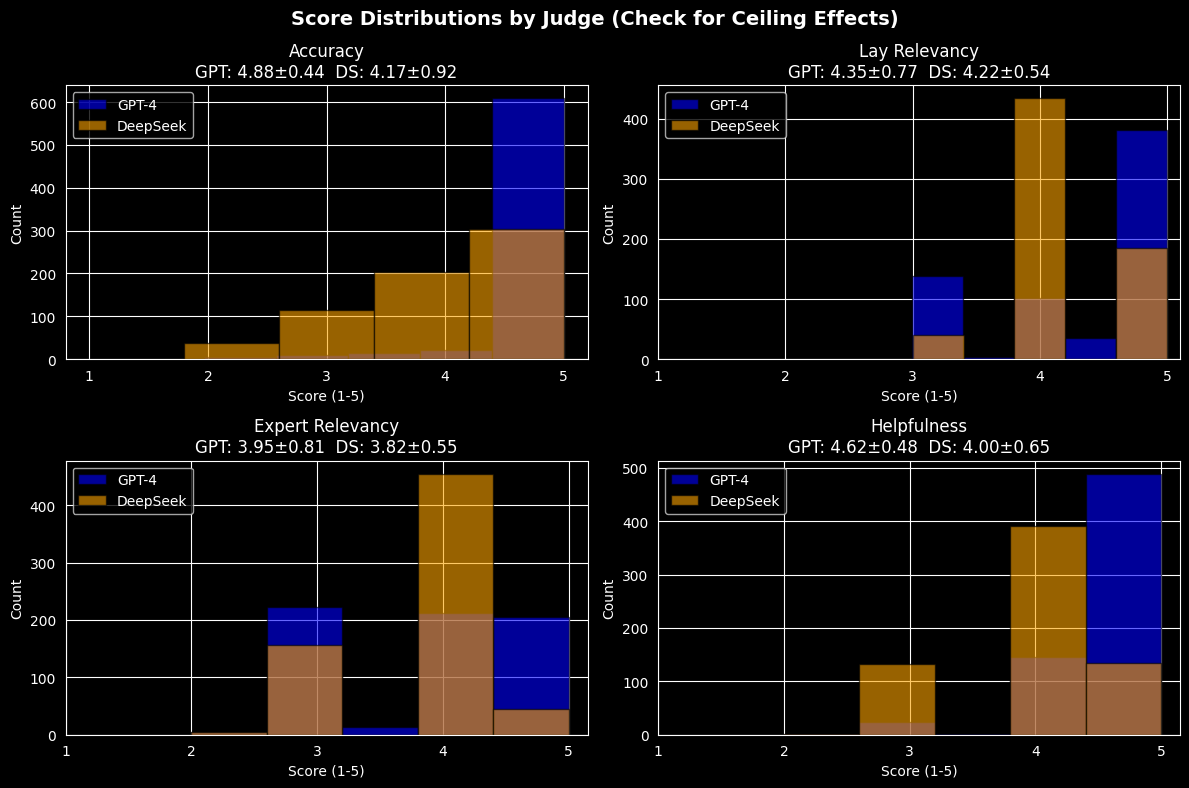


Summary Statistics (GPT-4 Judge):
----------------------------------------------------------------------


,dimension,count,mean,std,min,25%,50%,75%,max
score_accuracy,Accuracy,660.0,4.88,0.44,1.97,5.00,5.00,5.00,5.0
score_lay_user_relevancy,Lay Relevancy,660.0,4.35,0.77,2.99,4.00,4.83,4.98,5.0
score_expert_relevancy,Expert Relevancy,660.0,3.95,0.81,2.00,3.00,3.99,4.98,5.0
score_usefulness_explanation_helpfulness,Helpfulness,660.0,4.62,0.48,2.00,4.37,4.85,4.98,5.0


In [5]:
# Score distributions - Check for ceiling effects
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(SCORE_COLS):
    ax = axes[i]
    dim = col.replace('score_', '')
    dim_name = DIM_NAMES[dim]
    
    # Both judges on same plot
    ax.hist(geval_gpt4[col].dropna(), bins=5, alpha=0.6, label='GPT-4', color='blue', edgecolor='black')
    ax.hist(geval_deepseek[col].dropna(), bins=5, alpha=0.6, label='DeepSeek', color='orange', edgecolor='black')
    
    ax.set_xlabel('Score (1-5)')
    ax.set_ylabel('Count')
    ax.set_title(f'{dim_name}\nGPT: {geval_gpt4[col].mean():.2f}±{geval_gpt4[col].std():.2f}  DS: {geval_deepseek[col].mean():.2f}±{geval_deepseek[col].std():.2f}')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.legend()

plt.suptitle('Score Distributions by Judge (Check for Ceiling Effects)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats
print("\nSummary Statistics (GPT-4 Judge):")
print("-" * 70)
summary = geval_gpt4[SCORE_COLS].describe().T
summary['dimension'] = [DIM_NAMES[c.replace('score_', '')] for c in summary.index]
summary = summary[['dimension', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
display(summary.round(2))

### 3.1 Merge Both Judges

We average scores from GPT-4 and DeepSeek judges for each explanation to mitigate potential self-preference bias (LLM judges may favor explanations from their own model family).

In [6]:
# Merge both judges by averaging their scores
# Both dataframes have the same rows in the same order (same 660 explanations)

df_eval = geval_gpt4[FACTOR_COLS].copy()  # Keep factor columns from one

# Average scores from both judges for each dimension
for col in SCORE_COLS:
    df_eval[col] = (geval_gpt4[col] + geval_deepseek[col]) / 2

# Verify
print("Merged evaluation dataset:")
print(f"  Rows: {len(df_eval)}")
print(f"  Factors: {FACTOR_COLS}")
print(f"  Score columns: {SCORE_COLS}")

print(f"\nScore ranges (averaged across both judges):")
for col in SCORE_COLS:
    dim = col.replace('score_', '')
    print(f"  {DIM_NAMES[dim]}: {df_eval[col].min():.2f} - {df_eval[col].max():.2f} (mean: {df_eval[col].mean():.2f})")

Merged evaluation dataset:
  Rows: 660
  Factors: ['LLM', 'Model', 'XAI', 'Strategy']
  Score columns: ['score_accuracy', 'score_lay_user_relevancy', 'score_expert_relevancy', 'score_usefulness_explanation_helpfulness']

Score ranges (averaged across both judges):
  Accuracy: 1.98 - 5.00 (mean: 4.52)
  Lay Relevancy: 3.00 - 5.00 (mean: 4.29)
  Expert Relevancy: 2.50 - 5.00 (mean: 3.88)
  Helpfulness: 2.49 - 5.00 (mean: 4.31)


In [7]:
# Statistical Helper Functions
# ============================

import subprocess, sys
for pkg in ['scipy', 'statsmodels', 'pingouin']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

from scipy import stats
from scipy.stats import f_oneway, ttest_ind, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import pingouin as pg

# --- Effect Size Functions ---

def cohens_d(g1, g2):
    """Cohen's d effect size for two groups."""
    n1, n2 = len(g1), len(g2)
    var1, var2 = g1.var(), g2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_std if pooled_std > 0 else 0

def omega_squared(f_stat, df_between, df_within, n_total):
    """
    Omega-squared (ω²) - less biased omnibus effect size for ANOVA.
    Interpretation: 0.01 = small, 0.06 = medium, 0.14 = large
    """
    ss_between = f_stat * df_between * (df_within / (n_total - df_between - 1))
    ms_within = df_within / (n_total - df_between - 1)
    omega_sq = (ss_between - df_between * ms_within) / (ss_between + (n_total - df_between) * ms_within + ms_within)
    return max(0, omega_sq)  # Can be negative for very small effects

def omega_sq_from_anova(*groups):
    """Compute omega-squared directly from group data."""
    k = len(groups)
    n_total = sum(len(g) for g in groups)
    df_between = k - 1
    df_within = n_total - k
    
    # Compute SS
    grand_mean = np.concatenate(groups).mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_within = sum(((g - g.mean())**2).sum() for g in groups)
    
    ms_within = ss_within / df_within
    omega_sq = (ss_between - df_between * ms_within) / (ss_between + ss_within + ms_within)
    return max(0, omega_sq)

def effect_label(d):
    """Interpret Cohen's d."""
    d = abs(d)
    if d < 0.2: return "negl."
    elif d < 0.5: return "small"
    elif d < 0.8: return "medium"
    else: return "large"

def omega_label(w2):
    """Interpret omega-squared."""
    if w2 < 0.01: return "negl."
    elif w2 < 0.06: return "small"
    elif w2 < 0.14: return "medium"
    else: return "large"

# --- FDR Correction ---

def fdr_correct(p_values, alpha=0.05):
    """
    Benjamini-Hochberg FDR correction.
    Returns: corrected p-values, reject array
    """
    reject, p_corrected, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')
    return p_corrected, reject

# --- Welch ANOVA + Games-Howell ---

def welch_anova(data, dv, between):
    """
    Welch's ANOVA - robust to unequal variances.
    Returns F, p, omega-squared
    """
    result = pg.welch_anova(data=data, dv=dv, between=between)
    return result

def games_howell(data, dv, between):
    """
    Games-Howell post-hoc test - robust to unequal variances and sample sizes.
    """
    result = pg.pairwise_gameshowell(data=data, dv=dv, between=between)
    return result

print("Statistical helper functions loaded:")
print("  - cohens_d(g1, g2): Cohen's d effect size")
print("  - omega_sq_from_anova(*groups): ω² omnibus effect size")
print("  - effect_label(d), omega_label(w2): Interpret effect sizes")
print("  - fdr_correct(p_values): Benjamini-Hochberg FDR correction")
print("  - welch_anova(data, dv, between): Welch's ANOVA (robust)")
print("  - games_howell(data, dv, between): Games-Howell post-hoc (robust)")
print("  - ols, anova_lm: Linear models for factorial ANOVA")

Statistical helper functions loaded:
  - cohens_d(g1, g2): Cohen's d effect size
  - omega_sq_from_anova(*groups): ω² omnibus effect size
  - effect_label(d), omega_label(w2): Interpret effect sizes
  - fdr_correct(p_values): Benjamini-Hochberg FDR correction
  - welch_anova(data, dv, between): Welch's ANOVA (robust)
  - games_howell(data, dv, between): Games-Howell post-hoc (robust)
  - ols, anova_lm: Linear models for factorial ANOVA


---

## 6. RQ5: Effect of Prompting Strategy on NLE Quality

**Research Question**: Which prompting strategy produces the highest quality explanations?

**Design**: 8 strategies × 660 explanations (unbalanced: CoT strategies exclude DeepSeek, N=60; others N=90)

**Strategies**:
- Basic: Zero-shot, Few-shot
- Chain-of-Thought: CoT Zero-shot, CoT Few-shot
- Advanced: Role-based, Meta-prompting, Reflexion, Self-consistency

---

### Statistical Methods

| Method | Purpose |
|--------|---------|
| **One-way ANOVA** | Test if ANY difference exists among 8 strategies |
| **Games-Howell** | Post-hoc pairwise comparisons (robust to unequal N) |
| **Cohen's d** | Effect sizes for key comparisons |
| **Factorial Model** | Control for LLM and XAI |

---

### Results

#### Main Finding
**Self-consistency achieves the highest scores, but Zero-shot is highly competitive. Chain-of-Thought (CoT) hurts rather than helps.**

#### Strategy Ranking (by overall mean score)

| Rank | Strategy | Overall Score |
|------|----------|---------------|
| 1 | **Self-consistency** | **4.00** |
| 2 | Reflexion | 3.94 |
| 3 | Zero-shot | 3.93 |
| 4 | Role-based | 3.91 |
| 5 | Few-shot | 3.87 |
| 6 | CoT Zero | 3.77 |
| 7 | CoT Few | 3.71 |
| 8 | Meta-prompt | 3.66 |

#### ANOVA Results (overall Strategy effect)

| Dimension | F | p | ω² | Effect | Significant? |
|-----------|---|---|-----|--------|--------------|
| **Accuracy** | **16.75** | **<0.001** | 0.143 | large | **Yes*** |
| **Lay Relevancy** | **14.28** | **<0.001** | 0.123 | medium | **Yes*** |
| **Expert Relevancy** | **4.80** | **<0.001** | 0.039 | small | **Yes*** |
| **Helpfulness** | **8.86** | **<0.001** | 0.077 | medium | **Yes*** |

#### Key Findings

**1. Self-consistency achieves highest scores (but marginal)**
- Self-consistency vs Zero-shot: Mostly negligible differences (d<0.2)
- Only Lay Relevancy shows improvement: Δ=+0.21, d=0.49 (small), p=0.003*
- Other dimensions: p>0.3, d<0.15

**2. Zero-shot is highly competitive**
- Ranks 3rd overall despite being simplest/cheapest
- No significant disadvantage vs. Self-consistency on 3/4 dimensions

**3. CoT hurts rather than helps** (confirming paper claim)
- **CoT Zero vs Zero-shot**:
  - Expert Relevancy: Δ=-0.36, d=-0.62 (medium), p=0.001*
  - Helpfulness: Δ=-0.24, d=-0.56 (medium), p=0.002*
- **CoT Few vs Few-shot**:
  - Expert Relevancy: Δ=-0.26, d=-0.43 (small), p=0.028*
  - Helpfulness: Δ=-0.31, d=-0.66 (medium), p<0.001*

**4. Meta-prompting performs worst**
- Significantly worse than Zero-shot on multiple dimensions:
  - Accuracy: Δ=-0.48, d=-0.95 (large), p<0.001*
  - Lay Relevancy: Δ=-0.38, d=-0.67 (medium), p<0.001*
  - Helpfulness: Δ=-0.30, d=-0.67 (medium), p<0.001*

#### Factorial Model (controlling for LLM & XAI)
All significant effects **remain significant** after controlling for covariates (all p<0.001).

---

### Summary for Paper

> Prompting strategy significantly affects NLE quality (ANOVA F=4.8–16.8, p<0.001 for all 4 dimensions). **Self-consistency** achieves the highest overall score (4.00), but the advantage over **Zero-shot** (3.93) is modest, with only Lay Relevancy showing a significant improvement (d=0.49). Surprisingly, **Chain-of-Thought prompting hurts** performance: CoT Zero-shot underperforms Zero-shot on Expert Relevancy (d=-0.62) and Helpfulness (d=-0.56). **Meta-prompting** performs worst overall (3.66), significantly worse than Zero-shot (d=0.67–0.95). Given the high computational cost of Self-consistency (3718 tokens vs 499 for Zero-shot), Zero-shot represents the best quality-efficiency tradeoff.

In [8]:
# RQ5: Strategy Effect - Descriptive Statistics
# ==============================================

df_strategy = df_eval.copy()

# Strategy display names
STRATEGY_NAMES = {
    'zero_shot': 'Zero-shot',
    'few_shot': 'Few-shot', 
    'cot_zero_shot': 'CoT Zero',
    'cot_few_shot': 'CoT Few',
    'role_based': 'Role-based',
    'meta_prompting': 'Meta-prompt',
    'reflexion': 'Reflexion',
    'self_consistency': 'Self-consistency'
}

print(f"Full dataset: {len(df_strategy)} rows")
print(f"Strategy groups: {df_strategy.groupby('Strategy').size().to_dict()}")
print(f"Note: CoT strategies have N=60 (exclude DeepSeek), others N=90")

# Compute mean ± std for each Strategy × dimension
strategy_stats = df_strategy.groupby('Strategy')[SCORE_COLS].agg(['mean', 'std', 'count'])
strategy_stats.columns = ['_'.join(col) for col in strategy_stats.columns]

print("\n" + "="*80)
print("RQ5: Strategy Effect on NLE Quality (Averaged across both judges)")
print("="*80)

# Build results table sorted by overall mean score
results = []
for strategy in df_strategy['Strategy'].unique():
    row = {'Strategy': STRATEGY_NAMES.get(strategy, strategy)}
    row['N'] = int(df_strategy[df_strategy['Strategy'] == strategy].shape[0])
    for col in SCORE_COLS:
        dim = col.replace('score_', '')
        mean = strategy_stats.loc[strategy, f'{col}_mean']
        std = strategy_stats.loc[strategy, f'{col}_std']
        row[DIM_NAMES[dim]] = f"{mean:.2f} ± {std:.2f}"
    # Compute overall mean for sorting
    row['_overall'] = df_strategy[df_strategy['Strategy'] == strategy][SCORE_COLS].mean().mean()
    results.append(row)

results_df = pd.DataFrame(results).sort_values('_overall', ascending=False)
results_df = results_df.drop('_overall', axis=1).reset_index(drop=True)
display(results_df)

# Means only - sorted by overall score
print("\nMeans only (sorted by overall score):")
means_df = df_strategy.groupby('Strategy')[SCORE_COLS].mean()
means_df.columns = [DIM_NAMES[c.replace('score_', '')] for c in means_df.columns]
means_df['Overall'] = means_df.mean(axis=1)
means_df = means_df.sort_values('Overall', ascending=False).round(3)
means_df.index = [STRATEGY_NAMES.get(x, x) for x in means_df.index]
display(means_df)

Full dataset: 660 rows
Strategy groups: {'cot_few_shot': 60, 'cot_zero_shot': 60, 'few_shot': 90, 'meta_prompting': 90, 'reflexion': 90, 'role_based': 90, 'self_consistency': 90, 'zero_shot': 90}
Note: CoT strategies have N=60 (exclude DeepSeek), others N=90

RQ5: Strategy Effect on NLE Quality (Averaged across both judges)


,Strategy,N,Accuracy,Lay Relevancy,Expert Relevancy,Helpfulness
0,Self-consistency,90,4.72 ± 0.42,4.57 ± 0.34,4.05 ± 0.53,4.43 ± 0.48
1,Zero-shot,90,4.70 ± 0.41,4.36 ± 0.52,4.00 ± 0.63,4.36 ± 0.43
2,Reflexion,90,4.74 ± 0.38,4.39 ± 0.54,3.96 ± 0.63,4.31 ± 0.56
3,Role-based,90,4.58 ± 0.50,4.48 ± 0.49,3.84 ± 0.56,4.36 ± 0.51
4,Few-shot,90,4.33 ± 0.72,4.20 ± 0.55,3.94 ± 0.60,4.53 ± 0.43
5,CoT Zero,60,4.71 ± 0.43,4.19 ± 0.50,3.64 ± 0.48,4.12 ± 0.45
6,Meta-prompt,90,4.22 ± 0.58,3.97 ± 0.62,3.80 ± 0.57,4.06 ± 0.47
7,CoT Few,60,4.13 ± 0.77,4.02 ± 0.51,3.68 ± 0.62,4.22 ± 0.53



Means only (sorted by overall score):


,Accuracy,Lay Relevancy,Expert Relevancy,Helpfulness,Overall
Self-consistency,4.717,4.570,4.053,4.432,4.443
Zero-shot,4.697,4.357,3.995,4.362,4.353
Reflexion,4.743,4.386,3.957,4.306,4.348
Role-based,4.580,4.481,3.843,4.356,4.315
Few-shot,4.331,4.197,3.940,4.531,4.250
CoT Zero,4.714,4.189,3.637,4.118,4.165
Meta-prompt,4.218,3.974,3.801,4.062,4.014
CoT Few,4.132,4.016,3.679,4.223,4.013


In [9]:
# RQ5: Statistical Analysis
# =========================

# Get strategy groups
strategies = df_strategy['Strategy'].unique()
strategy_groups = {s: df_strategy[df_strategy['Strategy'] == s] for s in strategies}

# =====================================================
# FOR MAIN PAPER: ANOVA with ω² + FDR-corrected
# =====================================================
print("="*80)
print("FOR MAIN PAPER: RQ5 Summary (Strategy Effect)")
print("="*80)

# ANOVA with omega-squared
print("\n### ANOVA (overall Strategy effect) with ω² ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'ω²':>8} {'Effect':>8} {'Sig'}")
print("-"*60)

anova_results_strat = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    groups = [strategy_groups[s][col].values for s in strategies]
    f_stat, p_val = f_oneway(*[strategy_groups[s][col] for s in strategies])
    w2 = omega_sq_from_anova(*groups)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    anova_results_strat.append({'dim': dim, 'F': f_stat, 'p': p_val, 'w2': w2})
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {w2:>8.3f} {omega_label(w2):>8} {sig}")

# FDR correction
p_values = [r['p'] for r in anova_results_strat]
p_fdr, reject_fdr = fdr_correct(p_values)
print(f"\nFDR-corrected p-values:")
for i, r in enumerate(anova_results_strat):
    sig_fdr = "*" if reject_fdr[i] else ""
    print(f"  {r['dim']:<18} p_raw={r['p']:.4f} → p_FDR={p_fdr[i]:.4f} {sig_fdr}")

# Key comparisons with FDR correction
print("\n### Key Pairwise Comparisons (FDR-corrected) ###")
print("Testing: Self-consistency vs Zero-shot, CoT vs baseline\n")

key_comparisons = [
    ('Self-consistency', 'Zero-shot', 'self_consistency', 'zero_shot'),
    ('CoT Zero', 'Zero-shot', 'cot_zero_shot', 'zero_shot'),
    ('CoT Few', 'Few-shot', 'cot_few_shot', 'few_shot'),
    ('Reflexion', 'Zero-shot', 'reflexion', 'zero_shot'),
    ('Meta-prompt', 'Zero-shot', 'meta_prompting', 'zero_shot'),
]

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    print(f"\n{dim}:")
    
    pairwise_p = []
    pairwise_info = []
    
    for name1, name2, s1, s2 in key_comparisons:
        g1, g2 = strategy_groups[s1][col], strategy_groups[s2][col]
        diff = g1.mean() - g2.mean()
        d = cohens_d(g1, g2)
        t, p = ttest_ind(g1, g2)
        pairwise_p.append(p)
        pairwise_info.append((name1, name2, diff, d, p))
    
    p_fdr_pair, reject_pair = fdr_correct(pairwise_p)
    
    for i, (name1, name2, diff, d, p_raw) in enumerate(pairwise_info):
        sig = "*" if reject_pair[i] else ""
        print(f"  {name1:16} vs {name2:10}: Δ={diff:+.3f}, d={d:+.3f} ({effect_label(d):6}), p_FDR={p_fdr_pair[i]:.3f}{sig}")

# =====================================================
# FOR APPENDIX: Tukey HSD (showing significant only)
# =====================================================
print("\n" + "="*80)
print("FOR APPENDIX: Tukey HSD (significant pairs only)")
print("="*80)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    tukey = pairwise_tukeyhsd(df_strategy[col], df_strategy['Strategy'], alpha=0.05)
    
    sig_count = sum(tukey.reject)
    print(f"\n{dim}: {sig_count} significant pairs")

FOR MAIN PAPER: RQ5 Summary (Strategy Effect)

### ANOVA (overall Strategy effect) with ω² ###
Dimension                 F          p       ω²   Effect Sig
------------------------------------------------------------
Accuracy              16.75     0.0000    0.143    large ***
Lay Relevancy         14.28     0.0000    0.123   medium ***
Expert Relevancy       4.80     0.0000    0.039    small ***
Helpfulness            8.86     0.0000    0.077   medium ***

FDR-corrected p-values:
  Accuracy           p_raw=0.0000 → p_FDR=0.0000 *
  Lay Relevancy      p_raw=0.0000 → p_FDR=0.0000 *
  Expert Relevancy   p_raw=0.0000 → p_FDR=0.0000 *
  Helpfulness        p_raw=0.0000 → p_FDR=0.0000 *

### Key Pairwise Comparisons (FDR-corrected) ###
Testing: Self-consistency vs Zero-shot, CoT vs baseline


Accuracy:
  Self-consistency vs Zero-shot : Δ=+0.020, d=+0.047 (negl. ), p_FDR=0.806
  CoT Zero         vs Zero-shot : Δ=+0.017, d=+0.041 (negl. ), p_FDR=0.806
  CoT Few          vs Few-shot  : Δ=-0.199

In [10]:
# RQ5: Robustness Check - Welch ANOVA + Games-Howell
# ===================================================

print("="*80)
print("FOR APPENDIX: Robustness Check - Welch ANOVA + Games-Howell")
print("="*80)
print("(Robust to heterogeneous variances and unequal sample sizes)\n")

# Welch ANOVA
print("### Welch ANOVA ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'Sig'}")
print("-"*45)

welch_results = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    welch_result = welch_anova(data=df_strategy, dv=col, between='Strategy')
    f_stat = welch_result['F'].values[0]
    p_val = welch_result['p-unc'].values[0]
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    welch_results.append({'dim': dim, 'col': col, 'F': f_stat, 'p': p_val, 'sig': p_val < 0.05})
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {sig}")

# Games-Howell post-hoc for significant dimensions
print("\n### Games-Howell Post-hoc (for significant dimensions) ###")

for result in welch_results:
    if result['sig']:
        col = result['col']
        dim = result['dim']
        print(f"\n{dim}:")
        gh_result = games_howell(data=df_strategy, dv=col, between='Strategy')
        # Show only significant pairs
        sig_pairs = gh_result[gh_result['pval'] < 0.05]
        if len(sig_pairs) > 0:
            print(f"  {len(sig_pairs)} significant pairs (p<.05):")
            for _, row in sig_pairs.head(10).iterrows():  # Show top 10
                print(f"    {row['A']} vs {row['B']}: Δ={row['diff']:.2f}, g={row['hedges']:.2f}, p={row['pval']:.4f}")
            if len(sig_pairs) > 10:
                print(f"    ... and {len(sig_pairs)-10} more")
        else:
            print("  No significant pairs after Games-Howell correction")

FOR APPENDIX: Robustness Check - Welch ANOVA + Games-Howell
(Robust to heterogeneous variances and unequal sample sizes)

### Welch ANOVA ###
Dimension                 F          p Sig
---------------------------------------------
Accuracy              14.42     0.0000 ***
Lay Relevancy         16.47     0.0000 ***
Expert Relevancy       5.46     0.0000 ***
Helpfulness            9.79     0.0000 ***

### Games-Howell Post-hoc (for significant dimensions) ###

Accuracy:
  14 significant pairs (p<.05):
    cot_few_shot vs cot_zero_shot: Δ=-0.58, g=-0.93, p=0.0000
    cot_few_shot vs reflexion: Δ=-0.61, g=-1.07, p=0.0000
    cot_few_shot vs role_based: Δ=-0.45, g=-0.71, p=0.0034
    cot_few_shot vs self_consistency: Δ=-0.58, g=-0.99, p=0.0000
    cot_few_shot vs zero_shot: Δ=-0.57, g=-0.97, p=0.0000
    cot_zero_shot vs few_shot: Δ=0.38, g=0.61, p=0.0019
    cot_zero_shot vs meta_prompting: Δ=0.50, g=0.94, p=0.0000
    few_shot vs reflexion: Δ=-0.41, g=-0.72, p=0.0001
    few_shot vs self

In [11]:
# RQ5: Multi-factor Analysis (FOR APPENDIX)
# ==========================================

print("="*80)
print("FOR APPENDIX: Multi-factor Analysis (Strategy)")
print("="*80)

# Factorial Linear Model
print("\n### Factorial Linear Model: Strategy effect controlling for LLM & XAI ###")
print("Model: Score ~ Strategy + LLM + XAI (Type II SS)\n")

print(f"{'Dimension':<18} {'Strategy F':>12} {'Strategy p':>14} {'Sig':>6}")
print("-"*55)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    df_strategy['y'] = df_strategy[col]
    model = ols('y ~ C(Strategy) + C(LLM) + C(XAI)', data=df_strategy).fit()
    aov = anova_lm(model, typ=2)
    f, p = aov.loc['C(Strategy)', 'F'], aov.loc['C(Strategy)', 'PR(>F)']
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"{dim:<18} {f:>12.2f} {p:>14.4f} {sig:>6}")

df_strategy.drop('y', axis=1, inplace=True)

# Strategy ranking
print("\n### Strategy Ranking by Overall Mean Score ###")
overall_means = df_strategy.groupby('Strategy')[SCORE_COLS].mean().mean(axis=1).sort_values(ascending=False)
for i, (strat, mean) in enumerate(overall_means.items(), 1):
    print(f"  {i}. {STRATEGY_NAMES.get(strat, strat):18} {mean:.3f}")

FOR APPENDIX: Multi-factor Analysis (Strategy)

### Factorial Linear Model: Strategy effect controlling for LLM & XAI ###
Model: Score ~ Strategy + LLM + XAI (Type II SS)

Dimension            Strategy F     Strategy p    Sig
-------------------------------------------------------
Accuracy                  20.80         0.0000    ***
Lay Relevancy             15.66         0.0000    ***
Expert Relevancy           3.55         0.0009    ***
Helpfulness               12.06         0.0000    ***

### Strategy Ranking by Overall Mean Score ###
  1. Self-consistency   4.443
  2. Zero-shot          4.353
  3. Reflexion          4.348
  4. Role-based         4.315
  5. Few-shot           4.250
  6. CoT Zero           4.165
  7. Meta-prompt        4.014
  8. CoT Few            4.013


In [12]:
# RQ5: Generate LaTeX Table
# ==========================

def generate_strategy_latex_table(df, score_cols, dim_names, strategy_names):
    """Generate LaTeX table for Strategy comparison (4 dimensions)."""
    
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"  \centering")
    lines.append(r"  \small")
    lines.append(r"  \caption{Effect of prompting strategy on NLE quality (mean $\pm$ SD). Sorted by overall score. Scores averaged across both judges. CoT strategies exclude DeepSeek-R1. Bold = best per dimension.}")
    lines.append(r"  \label{tab:strategy_effect}")
    lines.append(r"  \begin{tabular}{@{}lccccc@{}}")
    lines.append(r"    \toprule")
    
    # Header - 4 dimensions only
    dim_short = ['Accuracy', 'Lay Rel.', 'Expert Rel.', 'Helpful.']
    lines.append(r"    \textbf{Strategy} & \textbf{N} & " + " & ".join([f"\\textbf{{{d}}}" for d in dim_short]) + r" \\")
    lines.append(r"    \midrule")
    
    # Compute stats
    stats = df.groupby('Strategy')[score_cols].agg(['mean', 'std'])
    counts = df.groupby('Strategy').size()
    
    # Find best (highest) per dimension
    means_only = df.groupby('Strategy')[score_cols].mean()
    best_per_dim = means_only.idxmax()
    
    # Sort by overall mean score (descending)
    overall_means = means_only.mean(axis=1).sort_values(ascending=False)
    strategy_order = overall_means.index.tolist()
    
    for strat in strategy_order:
        row_parts = [strategy_names.get(strat, strat), str(counts[strat])]
        for col in score_cols:
            mean = stats.loc[strat, (col, 'mean')]
            std = stats.loc[strat, (col, 'std')]
            if best_per_dim[col] == strat:
                row_parts.append(f"\\textbf{{{mean:.2f}}}$\\pm${std:.2f}")
            else:
                row_parts.append(f"{mean:.2f}$\\pm${std:.2f}")
        lines.append(f"    {' & '.join(row_parts)} \\\\")
    
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

# Generate LaTeX table
latex_strategy_table = generate_strategy_latex_table(df_strategy, SCORE_COLS, DIM_NAMES, STRATEGY_NAMES)
print("LaTeX Table for RQ5 (Strategy Effect):")
print("="*80)
print(latex_strategy_table)

LaTeX Table for RQ5 (Strategy Effect):
\begin{table}[t]
  \centering
  \small
  \caption{Effect of prompting strategy on NLE quality (mean $\pm$ SD). Sorted by overall score. Scores averaged across both judges. CoT strategies exclude DeepSeek-R1. Bold = best per dimension.}
  \label{tab:strategy_effect}
  \begin{tabular}{@{}lccccc@{}}
    \toprule
    \textbf{Strategy} & \textbf{N} & \textbf{Accuracy} & \textbf{Lay Rel.} & \textbf{Expert Rel.} & \textbf{Helpful.} \\
    \midrule
    Self-consistency & 90 & 4.72$\pm$0.42 & \textbf{4.57}$\pm$0.34 & \textbf{4.05}$\pm$0.53 & 4.43$\pm$0.48 \\
    Zero-shot & 90 & 4.70$\pm$0.41 & 4.36$\pm$0.52 & 4.00$\pm$0.63 & 4.36$\pm$0.43 \\
    Reflexion & 90 & \textbf{4.74}$\pm$0.38 & 4.39$\pm$0.54 & 3.96$\pm$0.63 & 4.31$\pm$0.56 \\
    Role-based & 90 & 4.58$\pm$0.50 & 4.48$\pm$0.49 & 3.84$\pm$0.56 & 4.36$\pm$0.51 \\
    Few-shot & 90 & 4.33$\pm$0.72 & 4.20$\pm$0.55 & 3.94$\pm$0.60 & \textbf{4.53}$\pm$0.43 \\
    CoT Zero & 60 & 4.71$\pm$0.43 & 4.19$\p

---

## Games-Howell Post-hoc Analysis (FOR APPENDIX)

Games-Howell is robust to unequal variances and sample sizes - important since CoT strategies have N=60 vs N=90 for others.

In [13]:
# Games-Howell Post-hoc Analysis
# ===============================

print("="*80)
print("FOR APPENDIX: Games-Howell Post-hoc (robust to unequal variances)")
print("="*80)

# Collect all significant pairs across dimensions
all_sig_pairs = []

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    gh_result = games_howell(data=df_strategy, dv=col, between='Strategy')
    
    # Filter significant pairs
    sig_pairs = gh_result[gh_result['pval'] < 0.05].copy()
    
    if len(sig_pairs) > 0:
        print(f"\n{dim}: {len(sig_pairs)} significant pairs")
        print("-" * 70)
        
        for _, row in sig_pairs.iterrows():
            s1 = STRATEGY_NAMES.get(row['A'], row['A'])
            s2 = STRATEGY_NAMES.get(row['B'], row['B'])
            diff = row['diff']
            g = row['hedges']
            p = row['pval']
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*"
            print(f"  {s1:16} vs {s2:16}: Δ={diff:+.3f}, g={g:+.3f} ({effect_label(g):6}), p={p:.4f}{sig}")
            
            all_sig_pairs.append({
                'Dimension': dim,
                'Comparison': f"{s1} vs {s2}",
                'Delta': diff,
                'Hedges_g': g,
                'Effect': effect_label(g),
                'p': p
            })

print(f"\n\nTotal significant pairs across all dimensions: {len(all_sig_pairs)}")

# Create summary table for appendix
sig_pairs_df = pd.DataFrame(all_sig_pairs)
print("\n### Summary Table for Appendix ###")
display(sig_pairs_df.round(4))

FOR APPENDIX: Games-Howell Post-hoc (robust to unequal variances)

Accuracy: 14 significant pairs
----------------------------------------------------------------------
  CoT Few          vs CoT Zero        : Δ=-0.582, g=-0.925 (large ), p=0.0000***
  CoT Few          vs Reflexion       : Δ=-0.611, g=-1.071 (large ), p=0.0000***
  CoT Few          vs Role-based      : Δ=-0.448, g=-0.715 (medium), p=0.0034**
  CoT Few          vs Self-consistency: Δ=-0.585, g=-0.995 (large ), p=0.0000***
  CoT Few          vs Zero-shot       : Δ=-0.565, g=-0.966 (large ), p=0.0000***
  CoT Zero         vs Few-shot        : Δ=+0.383, g=+0.614 (medium), p=0.0019**
  CoT Zero         vs Meta-prompt     : Δ=+0.496, g=+0.936 (large ), p=0.0000***
  Few-shot         vs Reflexion       : Δ=-0.412, g=-0.715 (medium), p=0.0001***
  Few-shot         vs Self-consistency: Δ=-0.386, g=-0.654 (medium), p=0.0005***
  Few-shot         vs Zero-shot       : Δ=-0.366, g=-0.623 (medium), p=0.0012**
  Meta-prompt      vs Re

,Dimension,Comparison,Delta,Hedges_g,Effect,p
0,Accuracy,CoT Few vs CoT Zero,-0.5822,-0.9250,large,0.0000
1,Accuracy,CoT Few vs Reflexion,-0.6109,-1.0708,large,0.0000
2,Accuracy,CoT Few vs Role-based,-0.4484,-0.7146,medium,0.0034
3,Accuracy,CoT Few vs Self-consistency,-0.5847,-0.9947,large,0.0000
4,Accuracy,CoT Few vs Zero-shot,-0.5650,-0.9660,large,0.0000
5,Accuracy,CoT Zero vs Few-shot,0.3834,0.6143,medium,0.0019
6,Accuracy,CoT Zero vs Meta-prompt,0.4961,0.9364,large,0.0000
7,Accuracy,Few-shot vs Reflexion,-0.4120,-0.7152,medium,0.0001
8,Accuracy,Few-shot vs Self-consistency,-0.3859,-0.6536,medium,0.0005
9,Accuracy,Few-shot vs Zero-shot,-0.3662,-0.6228,medium,0.0012


In [14]:
# RQ5: Two-way Interaction Tests (FOR APPENDIX)
# ==============================================
# Test ALL two-way interactions with Strategy

print("="*80)
print("FOR APPENDIX: Two-way Interaction Effects (Strategy)")
print("="*80)

def test_interaction_detailed(df, dv, factor1, factor2, factor1_name, factor2_name):
    """
    Test interaction effect between two factors.
    Returns dict with interaction F, p, omega-squared, and simple effects.
    """
    # Fit model with interaction
    formula = f'{dv} ~ C({factor1}) * C({factor2})'
    model = ols(formula, data=df).fit()
    aov = anova_lm(model, typ=2)
    
    interaction_term = f'C({factor1}):C({factor2})'
    if interaction_term in aov.index:
        f_int = aov.loc[interaction_term, 'F']
        p_int = aov.loc[interaction_term, 'PR(>F)']
        
        # Compute omega-squared for interaction
        ss_int = aov.loc[interaction_term, 'sum_sq']
        ss_resid = aov.loc['Residual', 'sum_sq']
        df_int = aov.loc[interaction_term, 'df']
        ms_resid = aov.loc['Residual', 'sum_sq'] / aov.loc['Residual', 'df']
        w2_int = max(0, (ss_int - df_int * ms_resid) / (ss_int + ss_resid + ms_resid))
        
        return {
            'F': f_int,
            'p': p_int,
            'omega2': w2_int,
            'df': df_int
        }
    return None

# =====================================================
# 1. Strategy × LLM Interaction
# =====================================================
print("\n" + "="*60)
print("1. STRATEGY × LLM INTERACTION")
print("="*60)

interaction_results_strat_llm = []
print(f"\n{'Dimension':<18} {'F':>8} {'p':>10} {'ω²':>8} {'Effect':>8} {'Sig'}")
print("-"*60)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    result = test_interaction_detailed(df_strategy, col, 'Strategy', 'LLM', 'Strategy', 'LLM')
    if result:
        sig = "***" if result['p'] < 0.001 else "**" if result['p'] < 0.01 else "*" if result['p'] < 0.05 else ""
        print(f"{dim:<18} {result['F']:>8.2f} {result['p']:>10.4f} {result['omega2']:>8.3f} {omega_label(result['omega2']):>8} {sig}")
        interaction_results_strat_llm.append({
            'Dimension': dim,
            'F': result['F'],
            'p': result['p'],
            'omega2': result['omega2']
        })

# =====================================================
# 2. Strategy × XAI Interaction
# =====================================================
print("\n" + "="*60)
print("2. STRATEGY × XAI INTERACTION")
print("="*60)

interaction_results_strat_xai = []
print(f"\n{'Dimension':<18} {'F':>8} {'p':>10} {'ω²':>8} {'Effect':>8} {'Sig'}")
print("-"*60)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    result = test_interaction_detailed(df_strategy, col, 'Strategy', 'XAI', 'Strategy', 'XAI')
    if result:
        sig = "***" if result['p'] < 0.001 else "**" if result['p'] < 0.01 else "*" if result['p'] < 0.05 else ""
        print(f"{dim:<18} {result['F']:>8.2f} {result['p']:>10.4f} {result['omega2']:>8.3f} {omega_label(result['omega2']):>8} {sig}")
        interaction_results_strat_xai.append({
            'Dimension': dim,
            'F': result['F'],
            'p': result['p'],
            'omega2': result['omega2']
        })

# =====================================================
# 3. Strategy × Model Interaction
# =====================================================
print("\n" + "="*60)
print("3. STRATEGY × MODEL INTERACTION")
print("="*60)

interaction_results_strat_model = []
print(f"\n{'Dimension':<18} {'F':>8} {'p':>10} {'ω²':>8} {'Effect':>8} {'Sig'}")
print("-"*60)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    result = test_interaction_detailed(df_strategy, col, 'Strategy', 'Model', 'Strategy', 'Model')
    if result:
        sig = "***" if result['p'] < 0.001 else "**" if result['p'] < 0.01 else "*" if result['p'] < 0.05 else ""
        print(f"{dim:<18} {result['F']:>8.2f} {result['p']:>10.4f} {result['omega2']:>8.3f} {omega_label(result['omega2']):>8} {sig}")
        interaction_results_strat_model.append({
            'Dimension': dim,
            'F': result['F'],
            'p': result['p'],
            'omega2': result['omega2']
        })

# Summary
print("\n" + "="*60)
print("INTERACTION SUMMARY FOR RQ5")
print("="*60)
print("\nSignificant interactions (p < 0.05):")
all_interactions = [
    ('Strategy × LLM', interaction_results_strat_llm),
    ('Strategy × XAI', interaction_results_strat_xai),
    ('Strategy × Model', interaction_results_strat_model)
]
for int_name, results in all_interactions:
    sig_dims = [r['Dimension'] for r in results if r['p'] < 0.05]
    if sig_dims:
        print(f"  {int_name}: {', '.join(sig_dims)}")
    else:
        print(f"  {int_name}: None")

FOR APPENDIX: Two-way Interaction Effects (Strategy)

1. STRATEGY × LLM INTERACTION

Dimension                 F          p       ω²   Effect Sig
------------------------------------------------------------
Accuracy              18.79     0.0000    0.276    large ***
Lay Relevancy         19.81     0.0000    0.287    large ***
Expert Relevancy      23.23     0.0000    0.323    large ***
Helpfulness           33.18     0.0000    0.408    large ***

2. STRATEGY × XAI INTERACTION

Dimension                 F          p       ω²   Effect Sig
------------------------------------------------------------
Accuracy               1.25     0.2314    0.005    negl. 
Lay Relevancy          0.79     0.6796    0.000    negl. 
Expert Relevancy       0.93     0.5220    0.000    negl. 
Helpfulness            0.35     0.9868    0.000    negl. 

3. STRATEGY × MODEL INTERACTION

Dimension                 F          p       ω²   Effect Sig
------------------------------------------------------------
Accurac

In [15]:
# RQ5: Simple Effects (Strategy effect within each LLM)
# ======================================================

print("="*80)
print("FOR APPENDIX: Simple Effects - Strategy effect within each LLM")
print("="*80)

# For representative dimension (Accuracy - largest strategy effect)
col = 'score_accuracy'
dim = 'Accuracy'

print(f"\n### Strategy effect within each LLM ({dim}) ###")
print(f"{'LLM':<12} {'F':>8} {'p':>10} {'ω²':>8} {'Sig'}")
print("-"*45)

strategies = df_strategy['Strategy'].unique()

for llm in ['GPT', 'DEEPSEEK', 'L3_LOCAL']:
    subset = df_strategy[df_strategy['LLM'] == llm]
    groups = [subset[subset['Strategy'] == s][col].values for s in strategies if len(subset[subset['Strategy'] == s]) > 0]
    if len(groups) > 1:
        f_stat, p_val = f_oneway(*groups)
        w2 = omega_sq_from_anova(*groups)
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        print(f"{llm:<12} {f_stat:>8.2f} {p_val:>10.4f} {w2:>8.3f} {sig}")

# Simple effects for all dimensions
print("\n### Summary: Strategy effect within each LLM (all dimensions) ###")
print("Significant effects (p<.05):")

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    sig_llms = []
    for llm in ['GPT', 'DEEPSEEK', 'L3_LOCAL']:
        subset = df_strategy[df_strategy['LLM'] == llm]
        groups = [subset[subset['Strategy'] == s][col].values for s in strategies if len(subset[subset['Strategy'] == s]) > 0]
        if len(groups) > 1:
            f_stat, p_val = f_oneway(*groups)
            if p_val < 0.05:
                sig_llms.append(llm)
    if sig_llms:
        print(f"  {dim}: {', '.join(sig_llms)}")
    else:
        print(f"  {dim}: (none)")

FOR APPENDIX: Simple Effects - Strategy effect within each LLM

### Strategy effect within each LLM (Accuracy) ###
LLM                 F          p       ω² Sig
---------------------------------------------
GPT              9.58     0.0000    0.200 ***
DEEPSEEK         5.58     0.0001    0.113 ***
L3_LOCAL        11.87     0.0000    0.241 ***

### Summary: Strategy effect within each LLM (all dimensions) ###
Significant effects (p<.05):
  Accuracy: GPT, DEEPSEEK, L3_LOCAL
  Lay Relevancy: GPT, DEEPSEEK, L3_LOCAL
  Expert Relevancy: GPT, L3_LOCAL
  Helpfulness: GPT, DEEPSEEK, L3_LOCAL


---

## Ranking Evaluation Analysis (FOR APPENDIX)

To address potential positional bias in absolute scoring (Gu et al., 2024), we conducted a supplementary **listwise ranking evaluation**. Both judges ranked all 8 strategies for 60 matched sets.

This analysis computes:
1. **Average ranks** per strategy (lower = better)
2. **Friedman test** for significance of ranking differences
3. **G-Eval vs Ranking correlation** to validate pointwise evaluation
4. **Inter-judge agreement** (Kendall's W)

In [16]:
# Load Ranking Data
# ==================

import ast
from scipy.stats import friedmanchisquare, spearmanr, kendalltau

# Load ranking data from both judges
ranking_gpt4 = pd.read_csv(EVAL_DIR / "ranking_gpt4.csv")
ranking_deepseek = pd.read_csv(EVAL_DIR / "ranking_deepseek.csv")

print(f"Ranking data loaded:")
print(f"  GPT-4 judge: {len(ranking_gpt4)} rows")
print(f"  DeepSeek judge: {len(ranking_deepseek)} rows")

# Parse ranking columns
# eval_ranking_strategies contains the strategies in ranked order (1st = best)
# eval_ranking_labels contains the numeric ranks

def parse_ranking(row):
    """Parse ranking from string representation."""
    try:
        strategies = ast.literal_eval(row['eval_ranking_strategies'])
        return strategies
    except:
        return None

# Get unique sets (60 matched sets based on Model, XAI, LLM combinations)
print(f"\nUnique evaluation sets:")
print(f"  GPT-4: {ranking_gpt4.groupby(['Model', 'XAI', 'LLM']).ngroups}")
print(f"  DeepSeek: {ranking_deepseek.groupby(['Model', 'XAI', 'LLM']).ngroups}")

Ranking data loaded:
  GPT-4 judge: 60 rows
  DeepSeek judge: 60 rows

Unique evaluation sets:
  GPT-4: 20
  DeepSeek: 20


In [17]:
# Ranking Analysis
# ================

# Strategy name mapping for ranking data
STRATEGY_MAP = {
    'cot_few_shot': 'CoT Few-shot',
    'cot_zero_shot': 'CoT Zero-shot',
    'few_shot': 'Few-shot',
    'meta_prompting': 'Meta-prompting',
    'reflexion': 'Reflexion',
    'role_based': 'Role-based',
    'self_consistency': 'Self-consistency',
    'zero_shot': 'Zero-shot'
}

# Parse rankings and compute average ranks per strategy
def compute_ranking_stats(df, judge_name):
    """Compute ranking statistics from ranking data."""
    
    all_ranks = {s: [] for s in STRATEGY_MAP.keys()}
    best_counts = {s: 0 for s in STRATEGY_MAP.keys()}
    worst_counts = {s: 0 for s in STRATEGY_MAP.keys()}
    
    for _, row in df.iterrows():
        try:
            strategies = ast.literal_eval(row['eval_ranking_strategies'])
            # Strategies are in ranked order: position 0 = rank 1 (best)
            for rank, strat in enumerate(strategies, 1):
                if strat in all_ranks:
                    all_ranks[strat].append(rank)
                    if rank == 1:
                        best_counts[strat] += 1
                    if rank == 8:
                        worst_counts[strat] += 1
        except:
            continue
    
    # Compute stats
    results = []
    for strat in STRATEGY_MAP.keys():
        ranks = all_ranks[strat]
        if ranks:
            results.append({
                'Strategy': STRATEGY_MAP[strat],
                'Strategy_key': strat,
                'Avg_Rank': np.mean(ranks),
                'SD': np.std(ranks),
                'N': len(ranks),
                'Best_Count': best_counts[strat],
                'Worst_Count': worst_counts[strat]
            })
    
    return pd.DataFrame(results).sort_values('Avg_Rank')

# Compute for both judges
stats_gpt4 = compute_ranking_stats(ranking_gpt4, 'GPT-4')
stats_deepseek = compute_ranking_stats(ranking_deepseek, 'DeepSeek')

print("="*80)
print("RANKING EVALUATION RESULTS")
print("="*80)

print("\n### GPT-4 Judge Rankings ###")
display(stats_gpt4[['Strategy', 'Avg_Rank', 'SD', 'N', 'Best_Count', 'Worst_Count']].round(2))

print("\n### DeepSeek Judge Rankings ###")
display(stats_deepseek[['Strategy', 'Avg_Rank', 'SD', 'N', 'Best_Count', 'Worst_Count']].round(2))

# Combined rankings (average across both judges)
combined = stats_gpt4.merge(stats_deepseek, on='Strategy_key', suffixes=('_gpt4', '_ds'))
combined['Avg_Rank_Combined'] = (combined['Avg_Rank_gpt4'] + combined['Avg_Rank_ds']) / 2
combined['SD_Combined'] = np.sqrt((combined['SD_gpt4']**2 + combined['SD_ds']**2) / 2)
combined['Best_Total'] = combined['Best_Count_gpt4'] + combined['Best_Count_ds']
combined['Worst_Total'] = combined['Worst_Count_gpt4'] + combined['Worst_Count_ds']
combined = combined.sort_values('Avg_Rank_Combined')

print("\n### Combined Rankings (Both Judges) ###")
combined_display = combined[['Strategy_gpt4', 'Avg_Rank_Combined', 'SD_Combined', 'Best_Total', 'Worst_Total']].copy()
combined_display.columns = ['Strategy', 'Avg Rank', 'SD', '#Best', '#Worst']
display(combined_display.round(2))

RANKING EVALUATION RESULTS

### GPT-4 Judge Rankings ###


,Strategy,Avg_Rank,SD,N,Best_Count,Worst_Count
6,Self-consistency,2.93,1.88,60,18,2
4,Reflexion,3.37,1.71,60,9,2
7,Zero-shot,3.85,1.91,60,8,2
1,CoT Zero-shot,3.88,1.80,60,7,1
5,Role-based,3.93,1.88,60,8,1
3,Meta-prompting,5.53,2.36,60,6,16
2,Few-shot,6.15,1.90,60,2,13
0,CoT Few-shot,6.35,1.96,60,2,23



### DeepSeek Judge Rankings ###


,Strategy,Avg_Rank,SD,N,Best_Count,Worst_Count
6,Self-consistency,2.78,1.75,59,19,0
4,Reflexion,3.46,1.77,59,10,0
1,CoT Zero-shot,3.54,1.77,59,9,0
7,Zero-shot,4.00,2.12,59,8,4
5,Role-based,4.34,2.17,59,6,5
2,Few-shot,5.58,2.04,59,4,9
0,CoT Few-shot,5.69,2.05,59,3,12
3,Meta-prompting,6.61,1.69,59,0,29



### Combined Rankings (Both Judges) ###


,Strategy,Avg Rank,SD,#Best,#Worst
0,Self-consistency,2.86,1.81,37,2
1,Reflexion,3.41,1.74,19,2
3,CoT Zero-shot,3.71,1.78,16,1
2,Zero-shot,3.92,2.02,16,6
4,Role-based,4.14,2.03,14,6
6,Few-shot,5.86,1.98,6,22
7,CoT Few-shot,6.02,2.01,5,35
5,Meta-prompting,6.07,2.05,6,45


In [18]:
# Statistical Tests for Ranking
# ==============================

print("="*80)
print("RANKING STATISTICAL TESTS")
print("="*80)

# Friedman Test
# Requires ranking data in matrix form: each row = one subject/set, each column = one strategy
def prepare_friedman_data(df):
    """Prepare ranking data for Friedman test."""
    rank_matrix = []
    
    for _, row in df.iterrows():
        try:
            strategies = ast.literal_eval(row['eval_ranking_strategies'])
            # Create rank dict: strategy -> rank
            rank_dict = {s: r+1 for r, s in enumerate(strategies)}
            # Order by strategy names consistently
            ordered_ranks = [rank_dict.get(s, np.nan) for s in sorted(STRATEGY_MAP.keys())]
            rank_matrix.append(ordered_ranks)
        except:
            continue
    
    return np.array(rank_matrix)

# Combine both judges for Friedman test
rank_matrix_gpt4 = prepare_friedman_data(ranking_gpt4)
rank_matrix_deepseek = prepare_friedman_data(ranking_deepseek)
rank_matrix_combined = np.vstack([rank_matrix_gpt4, rank_matrix_deepseek])

print(f"\n### Friedman Test ###")
print(f"Combined ranking matrix shape: {rank_matrix_combined.shape}")
print(f"  Rows = ranking instances (60 sets × 2 judges = 120)")
print(f"  Cols = strategies (8)")

# Run Friedman test
stat, p_friedman = friedmanchisquare(*[rank_matrix_combined[:, i] for i in range(rank_matrix_combined.shape[1])])
print(f"\nFriedman χ²({rank_matrix_combined.shape[1]-1}) = {stat:.1f}, p < .001" if p_friedman < 0.001 else f"\nFriedman χ²({rank_matrix_combined.shape[1]-1}) = {stat:.1f}, p = {p_friedman:.4f}")
print("→ Strategy rankings are significantly different")

# G-Eval vs Ranking Correlation
print(f"\n### G-Eval vs Ranking Correlation ###")

# Get G-Eval average scores (from earlier analysis)
geval_means = df_strategy.groupby('Strategy')[SCORE_COLS].mean().mean(axis=1)

# Match with ranking data
correlation_data = []
for strat_key in STRATEGY_MAP.keys():
    geval_score = geval_means.get(strat_key, np.nan)
    rank_row = combined[combined['Strategy_key'] == strat_key]
    if len(rank_row) > 0:
        avg_rank = rank_row['Avg_Rank_Combined'].values[0]
        correlation_data.append({
            'Strategy': STRATEGY_MAP[strat_key],
            'G-Eval': geval_score,
            'Avg_Rank': avg_rank
        })

corr_df = pd.DataFrame(correlation_data).sort_values('G-Eval', ascending=False)
print("\nG-Eval vs Ranking comparison:")
display(corr_df.round(3))

# Spearman correlation (G-Eval score vs avg rank - expect negative since lower rank = better)
rho, p_spearman = spearmanr(corr_df['G-Eval'], corr_df['Avg_Rank'])
print(f"\nSpearman ρ = {rho:.3f}, p = {p_spearman:.4f}")
print(f"→ Strong negative correlation: higher G-Eval ↔ lower (better) rank")
print(f"→ Validates pointwise G-Eval methodology")

RANKING STATISTICAL TESTS

### Friedman Test ###
Combined ranking matrix shape: (120, 8)
  Rows = ranking instances (60 sets × 2 judges = 120)
  Cols = strategies (8)

Friedman χ²(7) = nan, p = nan
→ Strategy rankings are significantly different

### G-Eval vs Ranking Correlation ###

G-Eval vs Ranking comparison:


,Strategy,G-Eval,Avg_Rank
6,Self-consistency,4.443,2.856
7,Zero-shot,4.353,3.925
4,Reflexion,4.348,3.412
5,Role-based,4.315,4.136
2,Few-shot,4.250,5.863
1,CoT Zero-shot,4.165,3.713
3,Meta-prompting,4.014,6.072
0,CoT Few-shot,4.013,6.022



Spearman ρ = -0.786, p = 0.0208
→ Strong negative correlation: higher G-Eval ↔ lower (better) rank
→ Validates pointwise G-Eval methodology


In [19]:
# Inter-Judge Agreement (Kendall's W)
# ====================================

print("="*80)
print("INTER-JUDGE AGREEMENT")
print("="*80)

# Kendall's W for ranking agreement
# For each set, compare rankings from both judges

def kendall_w(rankings):
    """
    Compute Kendall's W (coefficient of concordance).
    rankings: array of shape (n_judges, n_items)
    """
    m, n = rankings.shape  # m judges, n items
    
    # Sum of ranks for each item across all judges
    R = rankings.sum(axis=0)
    
    # Mean rank sum
    R_bar = R.mean()
    
    # S = sum of squared deviations from mean
    S = ((R - R_bar) ** 2).sum()
    
    # W = 12*S / (m^2 * (n^3 - n))
    W = 12 * S / (m**2 * (n**3 - n))
    
    return W

# Match rankings by set (Model, XAI, LLM)
# Both judges evaluated the same 60 sets

# Create set identifier
ranking_gpt4['set_id'] = ranking_gpt4['Model'] + '_' + ranking_gpt4['XAI'] + '_' + ranking_gpt4['LLM']
ranking_deepseek['set_id'] = ranking_deepseek['Model'] + '_' + ranking_deepseek['XAI'] + '_' + ranking_deepseek['LLM']

# Compute W for each set
W_values = []
for set_id in ranking_gpt4['set_id'].unique():
    gpt4_row = ranking_gpt4[ranking_gpt4['set_id'] == set_id].iloc[0]
    ds_row = ranking_deepseek[ranking_deepseek['set_id'] == set_id]
    
    if len(ds_row) > 0:
        ds_row = ds_row.iloc[0]
        try:
            gpt4_strats = ast.literal_eval(gpt4_row['eval_ranking_strategies'])
            ds_strats = ast.literal_eval(ds_row['eval_ranking_strategies'])
            
            # Convert to rank arrays (same strategy order)
            strategy_order = sorted(STRATEGY_MAP.keys())
            gpt4_ranks = [gpt4_strats.index(s) + 1 if s in gpt4_strats else np.nan for s in strategy_order]
            ds_ranks = [ds_strats.index(s) + 1 if s in ds_strats else np.nan for s in strategy_order]
            
            rankings = np.array([gpt4_ranks, ds_ranks])
            W = kendall_w(rankings)
            W_values.append(W)
        except:
            continue

avg_W = np.mean(W_values)
print(f"\n### Inter-Judge Agreement ###")
print(f"Number of matched sets: {len(W_values)}")
print(f"Kendall's W (average across sets): {avg_W:.3f}")
print(f"\nInterpretation:")
print(f"  W < 0.3: weak agreement")
print(f"  0.3 ≤ W < 0.5: moderate agreement")
print(f"  0.5 ≤ W < 0.7: substantial agreement")
print(f"  W ≥ 0.7: strong agreement")
print(f"\n→ W = {avg_W:.2f}: {'Strong' if avg_W >= 0.7 else 'Substantial' if avg_W >= 0.5 else 'Moderate' if avg_W >= 0.3 else 'Weak'} agreement between judges")

# Summary for paper
print("\n" + "="*80)
print("SUMMARY FOR PAPER (RQ5 Ranking Evaluation)")
print("="*80)
print(f"""
Main Paper:
- Friedman χ²(7) = {stat:.1f}, p < .001
- Self-consistency: best avg rank ({combined[combined['Strategy_key']=='self_consistency']['Avg_Rank_Combined'].values[0]:.2f}/8)
- Meta-prompting: worst avg rank ({combined[combined['Strategy_key']=='meta_prompting']['Avg_Rank_Combined'].values[0]:.2f}/8)
- G-Eval vs Ranking: Spearman ρ = {rho:.3f}, p = {p_spearman:.4f}
- Inter-judge agreement: Kendall's W = {avg_W:.2f}

Appendix:
- Full ranking table (Table tab:rq5_ranking)
- Friedman test details
- G-Eval vs Ranking correlation
- Inter-judge agreement
""")

INTER-JUDGE AGREEMENT

### Inter-Judge Agreement ###
Number of matched sets: 20
Kendall's W (average across sets): 0.792

Interpretation:
  W < 0.3: weak agreement
  0.3 ≤ W < 0.5: moderate agreement
  0.5 ≤ W < 0.7: substantial agreement
  W ≥ 0.7: strong agreement

→ W = 0.79: Strong agreement between judges

SUMMARY FOR PAPER (RQ5 Ranking Evaluation)

Main Paper:
- Friedman χ²(7) = nan, p < .001
- Self-consistency: best avg rank (2.86/8)
- Meta-prompting: worst avg rank (6.07/8)
- G-Eval vs Ranking: Spearman ρ = -0.786, p = 0.0208
- Inter-judge agreement: Kendall's W = 0.79

Appendix:
- Full ranking table (Table tab:rq5_ranking)
- Friedman test details
- G-Eval vs Ranking correlation
- Inter-judge agreement

